# Draft

In [153]:
import glob
from pathlib import Path
import warnings

import ot
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from scipy.spatial import distance

from src.repartition.data_loading import get_annotation, tif_to_real_mask
from src.repartition.data_analysis import *
from src.repartition.visualization import *
from src.repartition.constants import PROJECT_ROOT, PATH_PATIENT_DATA
from src.repartition.TissueCollection import * 
from src.repartition.geometry_funcs import * 

In [2]:
%load_ext autoreload
%autoreload 1
%aimport src.repartition.data_loading, src.repartition.data_analysis, src.repartition.visualization, src.repartition.constants, src.repartition.TissueCollection, src.repartition.geometry_funcs

## Load paths

In [3]:
project_root = PROJECT_ROOT
annot_dir = project_root / 'data/repartition/annotation/'
annotations_paths = glob.glob(str(annot_dir) + "/" +'*.tif')
#annotations_paths = np.array(annotations_paths)
# specific_samples = [
#     '25P22496',
#     '25P4979',
#     '25P991',
#     '25P27813',
#     '24P41454'
# ]

specific_samples = [
    '25P22496',
    '25P32590',
    '24P41454',
    '25P37094',
    '25P41417',
    '25P33673',
    '25P44865',
    '25P12607',
    '25P21057'
]

annotations_paths = [path for path in annotations_paths if id_patient(os.path.basename(path)) in specific_samples]
slides_annot = get_annotation(annotations_paths, tif_to_real_mask)

In [166]:
slides_tumor = get_tumor_slides(slides_annot)

In [84]:
def show_center_estimation(tumorbed, funcs, estimations):
    pts = [
            {"couleur": "lime", "symbole": "^"},
            {"couleur": "cyan", "symbole": "s"},
            {"couleur": "magenta", "symbole": "D"},
            {"couleur": "yellow", "symbole": "o"}
    ]

    plt.figure(figsize=(10, 6))

    coords = np.argwhere(tumorbed)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    h_pad = (y_max - y_min) * 0.20
    w_pad = (x_max - x_min) * 0.20

    plt.imshow(tumorbed, cmap='gray', origin='upper')

    for i, f in enumerate(funcs):
        y_coord, x_coord = estimations[i]
        plt.scatter(
            x_coord, y_coord, 
            color=pts[i]["couleur"], 
            marker=pts[i]["symbole"], 
            s=50,                 # s = taille du point
            label=f.__name__,       # le nom qui apparaîtra dans la légende
            edgecolors='black',    # un contour noir pour bien voir le point sur fond blanc/noir
            zorder=5               # s'assure que le point est dessiné au-dessus de l'image
        )

    # 6. Ajout et personnalisation de la légende
    # bbox_to_anchor permet de placer la légende à l'extérieur de l'image pour ne rien cacher
    plt.legend(
        title="Légende des points",
        loc='center left', 
        bbox_to_anchor=(1.05, 0.5),
        frameon=True,
        shadow=True,
    )

    # 7. Finitions et affichage
    plt.title("Estimation du centre du lit tumoral")
    plt.axis('off')
    plt.xlim(x_min - w_pad, x_max + w_pad)
    plt.ylim(y_max + h_pad, y_min - h_pad)
    plt.tight_layout() # Ajuste la fenêtre pour que la légende externe ne soit pas coupée
    plt.show()


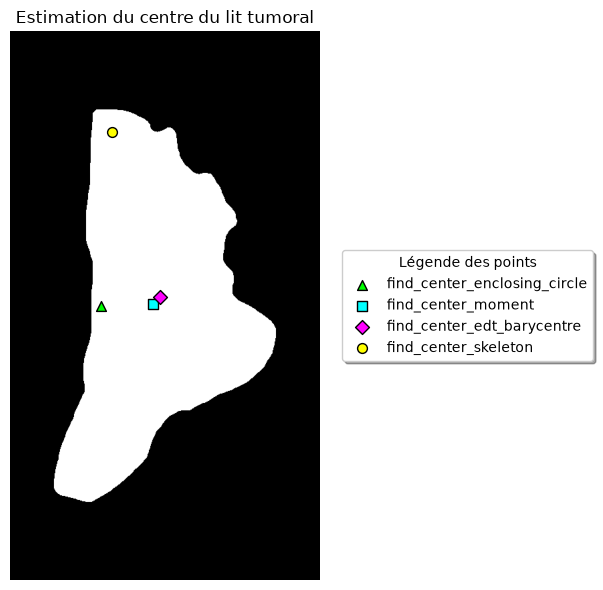

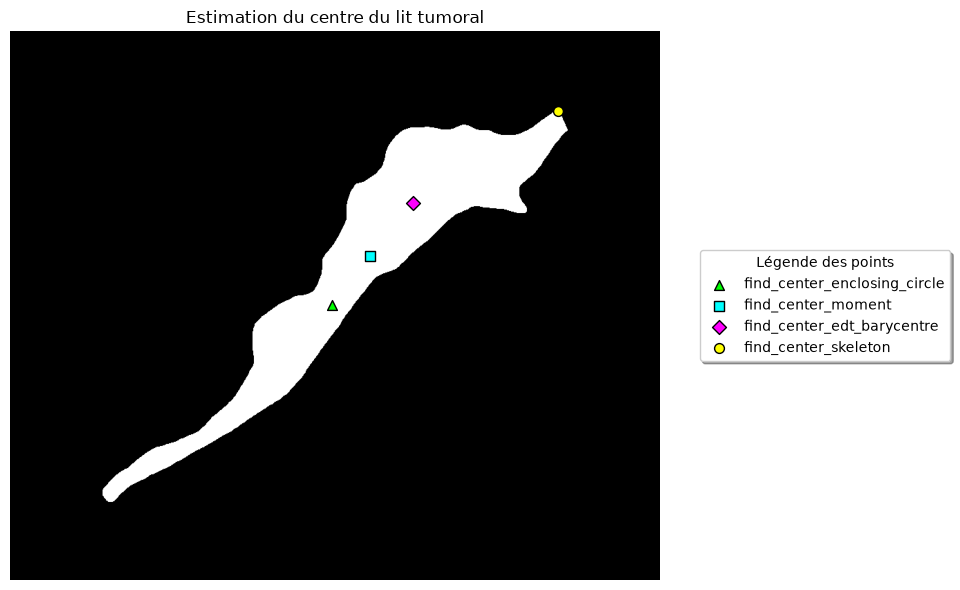

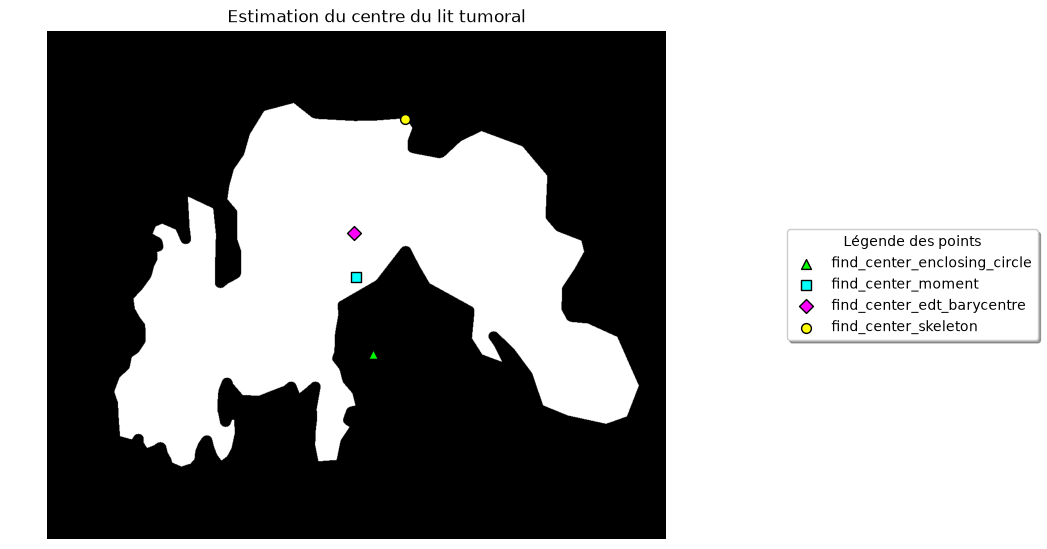

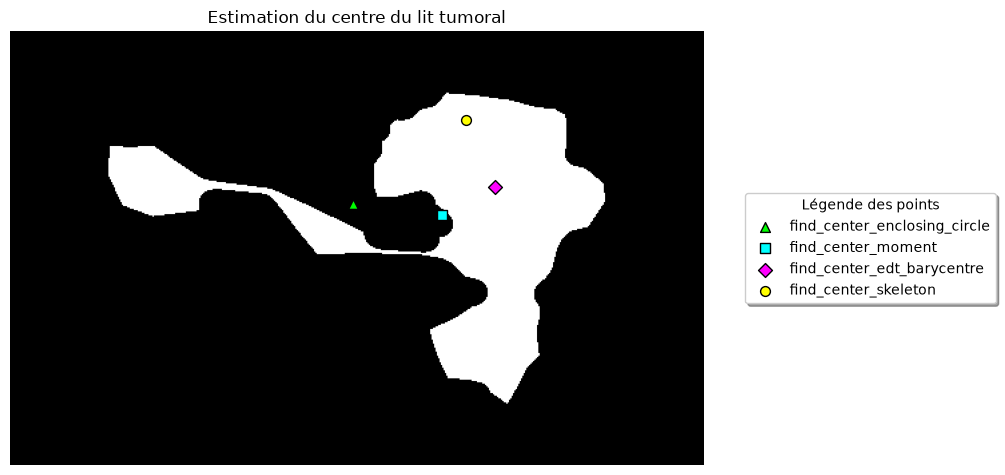

In [93]:
for id_sld, masks in slides_annot.items():
    show_center_estimation(masks['tumor_bed'], funcs, centers[id_sld])

In [25]:
from functools import partial

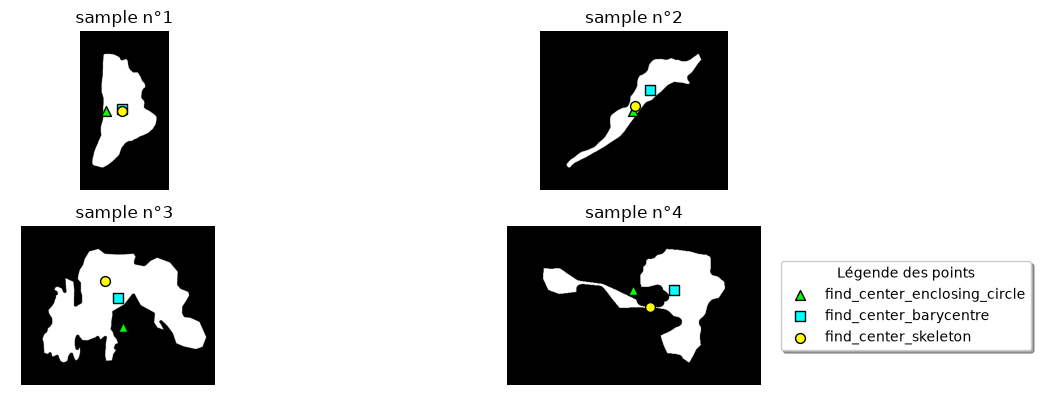

In [10]:

funcs = [
    find_center_enclosing_circle, 
    # partial(
    #     find_center_barycentre,
    #     with_edt=False,
    # ),
    find_center_barycentre,
    find_center_skeleton
]

pts = [
    {"couleur": "lime", "symbole": "^", "nom":'find_center_enclosing_circle'},
    {"couleur": "cyan", "symbole": "s", "nom":'find_center_barycentre'},
    #{"couleur": "magenta", "symbole": "D", "nom":'find_center_barycentre_edt'},
    {"couleur": "yellow", "symbole": "o", "nom":'find_center_skeleton'}
]

plt.figure(figsize=(12, 6))

for k, f in enumerate(funcs):
    
    for i, id_sld in enumerate(slides_annot.keys()):
        mask = slides_annot[id_sld]['tumor_bed']
        res = f(mask)
        center = res[0]['center'][::-1]
        img = res[0]['mask']

        coords = np.argwhere(img)
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        h_pad = (y_max - y_min) * 0.20
        w_pad = (x_max - x_min) * 0.20

        plt.subplot(3, 2, i+1)
        plt.imshow(img, cmap='gray')
        plt.scatter(
            center[0], center[1], 
            color=pts[k]["couleur"], 
            marker=pts[k]["symbole"], 
            s=50,                 # s = taille du point
            label=pts[k]["nom"],
            edgecolors='black',    # un contour noir pour bien voir le point sur fond blanc/noir
            zorder=5               # s'assure que le point est dessiné au-dessus de l'image
        )
        plt.title(f"sample n°{i+1}")

        plt.xlim(x_min - w_pad, x_max + w_pad)
        plt.ylim(y_max + h_pad, y_min - h_pad)
        plt.axis('off')

plt.legend(
    title="Légende des points",
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5),
    frameon=True,
    shadow=True,
)
plt.tight_layout()
plt.show()

In [30]:
from matplotlib.patches import Circle

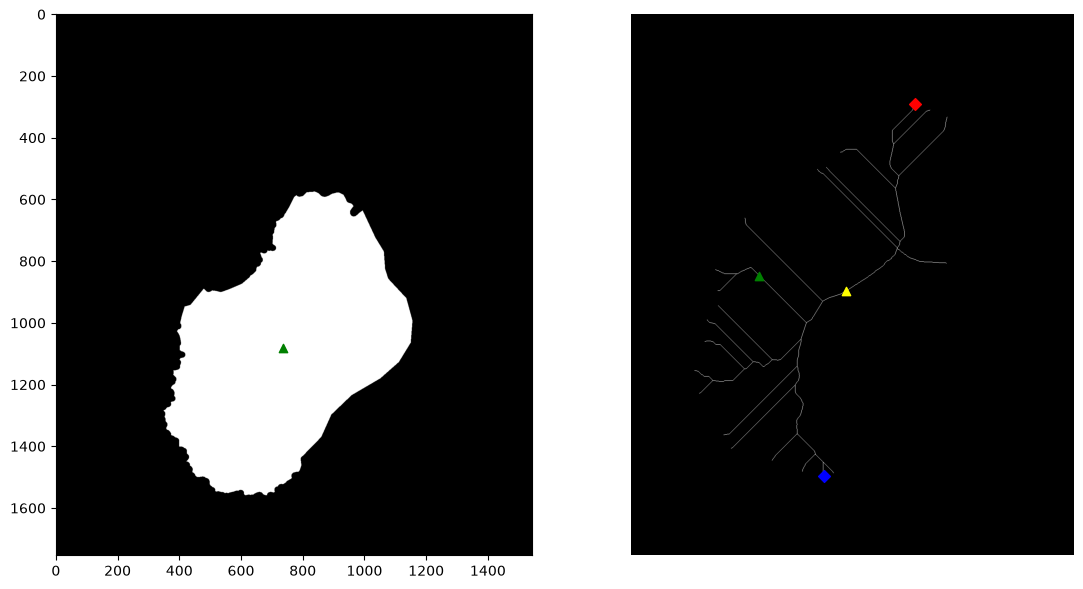

In [ ]:
f = find_center_skeleton
plt.figure(figsize=(12, 6))

id_sld = '24P41454_10_1'
mask = slides_annot[id_sld]['tumor_bed']
res, _= f(mask)
center = res[0]['center']
img = res[0]['mask']

coords = np.argwhere(img)
y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)
h_pad = (y_max - y_min) * 0.20
w_pad = (x_max - x_min) * 0.20

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.scatter(nc[1], nc[0], marker='^', color='green')

plt.subplot(1, 2, 2)
plt.imshow(skl, cmap='gray')
plt.scatter(center[1], center[0], marker='^', color='green')
plt.scatter(a[1], a[0], marker='D', color='blue')
plt.scatter(b[1], b[0], marker='D', color='red')
plt.scatter(nc[1], nc[0], marker='^', color='yellow')

plt.xlim(x_min - w_pad, x_max + w_pad)
plt.ylim(y_max + h_pad, y_min - h_pad)
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
def visualize_distance_map(image, skel_coords, distances, title):
    dist_map = np.full(image.shape, np.nan)
    coords = np.argwhere(image)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    h_pad = (y_max - y_min) * 0.20
    w_pad = (x_max - x_min) * 0.20
    
    for i, (y, x) in enumerate(skel_coords):
        if distances[i] >= 0:
            dist_map[y, x] = distances[i]
            
    plt.figure(figsize=(6, 8))
    plt.imshow(dist_map, cmap='magma')
    plt.colorbar(label='Distance (pixels)')
    plt.title('First pass')
    plt.xlim(x_min - w_pad, x_max + w_pad)
    plt.ylim(y_max + h_pad, y_min - h_pad)
    plt.axis('off');
    plt.show()

In [162]:
id_sld = 'BC.25P33673.6.27.1'
mask = slides_annot[id_sld]['tumor']
bed_mask = slides_annot[id_sld]['tumor_bed']

In [165]:
def get_spread_dist(contours):
    l = contours[:, :, 0].argmin()
    r = contours[:, :, 0].argmax()
    t = contours[:, :, 1].argmin()
    b = contours[:, :, 1].argmax()

    dist_lr = distance.euclidean(contours[l][0], contours[r][0])
    dist_tb = distance.euclidean(contours[t][0], contours[b][0])

    return max(dist_lr, dist_tb)

def compute_tumor_spread(tumor_mask, bed_mask):
    points = cv2.findNonZero(tumor_mask)
    hull = cv2.convexHull(points)

    bed_contour, _ = cv2.findContours(
                bed_mask.astype(np.uint8),
                cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    bed_contour = bed_contour[0]

    sp_tum = get_spread_dist(hull)
    sp_bed = get_spread_dist(bed_contour)

    area_between_tumors = cv2.contourArea(hull)
    global_area = np.count_nonzero(bed_mask)

    m = min(1, sp_tum/sp_bed) + min(1, area_between_tumors / global_area)

    return m, hull 
